# sc2ts on simulated pathogens

How well sc2ts recovers recombinants and the overall ARG when the truth is known, for
a range of simulated pathogens. The simulations and scoring are done by the Snakemake
pipeline in `simulations/slim` (see its README); this notebook reads the combined
results it keeps in `simulations/slim/summaries/{pathogen}/`, for every pathogen
found there, and makes `figures/slim_simulations.pdf` for the paper.

**Simulation.** For each pathogen, SLiM simulates a neutral, haploid Wright-Fisher
population that grows from a single founder to $N$ cases per generation over
`GROWTH_GENS` generations, then stays at that size up to `GENS` generations. The genome
has length $L$ and mutation rate `MU` per site per generation, and a fraction
`EFF_RECOMB` of births have two parents, with a single uniformly placed breakpoint.
Each generation is one sampling date for sc2ts. The parameters of each pathogen are in
the table below, from `simulations/slim/config.yaml`. There are 5 replicates of each
pathogen; tables give the mean over replicates and its range (min and max).

**Sampling and inference.** For each of the pathogen's numbers of samples per day, a
uniform random sample of that many individuals is taken from every generation (all
of it, if smaller), with the smaller samples a subset of the larger. sc2ts is run
with $k = 3, 4, 5$ and otherwise the parameters used for the Viridian ARG, except
that its time-traveller filtering is turned off: the simulated samples have exact
dates and no errors, so every sample is added on its own day. The final ARG is then
run through `sc2ts postprocess`, which adds samples identical to a node already in
the ARG ("exact matches") as nodes of their own.

**What counts as a recombinant.** A sample should be inferred to be a recombinant if it
is one itself, *or* if it inherits a recombination from an unsampled ancestor: walking
up its clonal line, it reaches a recombinant before reaching any individual placed in
the inferred ARG. Several samples can share one such recombinant ancestor; once sc2ts
has inferred that recombination in one of them, the rest correctly copy from it with
a single parent. So:

- **precision** is per sample: of the samples sc2ts matched with two parents, the
  fraction expected to be recombinants;
- **recall** is per recombination *event*: the fraction of recombinant ancestors for
  which at least one expected sample was matched with two parents.

Only samples placed in the ARG are scored.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import yaml

In [2]:
slim_dir = Path("../simulations/slim")
with open(slim_dir / "config.yaml") as f:
    config = yaml.safe_load(f)

summaries_dir = slim_dir / "summaries"
pathogens = sorted(path.name for path in summaries_dir.iterdir() if path.is_dir())


def load(name):
    return pd.concat(
        [pd.read_csv(summaries_dir / pathogen / f"{name}.csv") for pathogen in pathogens],
        ignore_index=True,
    )


# One row per run (replicate, number of samples per day and k).
summary = load("summary")
# One row per expected recombination event per run.
events = load("events")
# Samples, placed samples and exact matches per generation per run.
placement = load("placement")
# One row per recombinant node in the inferred ARG per run.
recombinants = load("recombinants")

k_values = sorted(summary.k.unique())
sample_sizes = {
    pathogen: sorted(summary[summary.pathogen == pathogen].samples_per_day.unique())
    for pathogen in pathogens
}
summary.groupby("pathogen").rep.nunique()

pathogen
coronavirus_like    5
flu_like            5
Name: rep, dtype: int64

## Pathogens

`mutations_per_genome` is the expected number of mutations per genome per generation,
and `mutations_per_run` the expected number along one lineage over the whole
simulation. The influenza-like epidemic runs for 100 days at one generation per day,
so accumulates far less diversity (about 10 mutations along a lineage) than the
coronavirus-like one (about 72 over 200 generations of 5.5 days), despite its higher
substitution rate per year. A SARS-CoV-like pathogen was also tried, but builds up
too little diversity in 100 days for sc2ts to find any recombinants (see the README).

In [3]:
rows = []
for pathogen in pathogens:
    params = config["pathogens"][pathogen]
    row = dict(params["slim"])
    row["mutations_per_genome"] = row["L"] * row["MU"]
    # Expected mutations along one lineage over the whole simulation.
    row["mutations_per_run"] = row["mutations_per_genome"] * row["GENS"]
    row["samples_per_day"] = ", ".join(str(s) for s in params["samples_per_day"])
    rows.append(row)
pd.DataFrame(rows, index=pd.Index(pathogens, name="pathogen"))

,N,GENS,GROWTH_GENS,L,MU,EFF_RECOMB,mutations_per_genome,mutations_per_run,samples_per_day
pathogen,,,,,,,,,
coronavirus_like,1000,200,20,30000,0.000012,0.005000,0.36000,72.000,"20, 100"
flu_like,1000000,100,50,13000,0.000008,0.000685,0.09789,9.789,"200, 1000"


In [4]:
# Pathogens are categorical (blue, orange); the larger number of samples per day
# is drawn solid and the smaller dashed. k is ordered, so one hue light to dark.
pathogen_colors = dict(zip(pathogens, ["#2a78d6", "#eb6834"]))
pathogen_labels = {"coronavirus_like": "Coronavirus-like", "flu_like": "Influenza-like"}
k_colors = dict(zip(k_values, ["#86b6ef", "#2a78d6", "#104281"]))


def s_style(pathogen, s):
    return "-" if s == max(sample_sizes[pathogen]) else "--"


grid_kwargs = dict(color="0.9", linewidth=0.6)

# The median breakpoint interval in the Viridian ARG, from the paper.
PAPER_MEDIAN_INTERVAL = 2018
PAPER_K = 4


def clean_axes(ax):
    ax.yaxis.grid(True, **grid_kwargs)
    ax.set_axisbelow(True)
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)


def over_replicates(df, columns, by=("pathogen", "samples_per_day", "k")):
    """Mean, min and max over replicates."""
    return df.groupby(list(by))[columns].agg(["mean", "min", "max"])

## Summary

Means over replicates. `exact_matches` is the number of samples added by
`sc2ts postprocess`, `held_back` the number sc2ts never added (none, as time-traveller
filtering is off). `sampled` is the number of samples that are recombinants
themselves, `expected` the number that should be inferred to be recombinants, and
`events` the number of distinct recombinant ancestors behind them.

In [5]:
counts = summary.groupby(["pathogen", "samples_per_day", "k"])[
    [
        "num_samples",
        "num_placed",
        "num_exact_matches",
        "num_held_back",
        "num_sampled_recombinants",
        "num_expected_recombinants",
        "num_events",
        "num_inferred_recombinants",
        "false_positives",
        "events_detected",
    ]
].mean().rename(columns=lambda c: c.replace("num_", "").replace("_recombinants", ""))
counts.round(1)

samples   placed  exact_matches  \
pathogen         samples_per_day k                                    
coronavirus_like 20              3   3892.0   3892.0          436.4   
                                 4   3892.0   3892.0          436.4   
                                 5   3892.0   3892.0          436.4   
                 100             3  19003.0  19003.0         5334.4   
                                 4  19003.0  19003.0         5334.6   
                                 5  19003.0  19003.0         5334.6   
flu_like         200             3  16987.0  16987.0         4656.6   
                                 4  16987.0  16987.0         4656.6   
                                 5  16987.0  16987.0         4656.6   
                 1000            3  79140.0  79140.0        24481.0   
                                 4  79140.0  79140.0        24482.0   
                                 5  79140.0  79140.0        24481.6   

                                    held_back  sampled  expected  events  \
pathogen         samples_per_day k                                         
coronavirus_like 20              3        0.0     22.8     591.4   164.8   
                                 4        0.0     22.8     591.4   164.8   
                                 5        0.0     22.8     591.4   164.8   
                 100             3        0.0     99.6     862.8   353.0   
                                 4        0.0     99.6     862.8   353.0   
                                 5        0.0     99.6     862.8   353.0   
flu_like         200             3        0.0     13.4     371.2   279.4   
                                 4        0.0     13.4     371.2   279.4   
                                 5        0.0     13.4     371.2   279.4   
                 1000            3        0.0     55.0    1633.4  1003.4   
                                 4        0.0     55.0    1633.4  1003.4   
                                 5        0.0     55.0    1633.4  1003.4   

                                    inferred  false_positives  events_detected  
pathogen         samples_per_day k                                              
coronavirus_like 20              3     155.4             17.2            128.8  
                                 4     136.6              5.6            123.4  
                                 5     125.0              3.0            115.8  
                 100             3     323.4              9.2            288.8  
                                 4     301.4              2.8            275.0  
                                 5     281.2              0.8            258.2  
flu_like         200             3      40.2              8.4             31.6  
                                 4       7.8              0.2              7.6  
                                 5       1.0              0.0              1.0  
                 1000            3     266.8             79.2            185.0  
                                 4      69.6              4.4             64.4  
                                 5      20.8              0.8             19.8

## Precision and recall

Raising $k$ trades recall for precision, as on the real data.

**Coronavirus-like.** Precision is high throughout: 0.89 and 0.97 at $k = 3$ (20 and
100 samples per day), 0.96 and 0.99 at $k = 4$, and 0.98 and 1.00 at $k = 5$. Recall
falls from 0.78-0.82 at $k = 3$ to 0.70-0.73 at $k = 5$ (0.75 and 0.78 at $k = 4$),
and is a little higher with 100 samples per day than with 20.

**Influenza-like.** Recall is low and falls steeply with $k$: 0.11 and 0.18 at $k = 3$
(200 and 1,000 per day), 0.03 and 0.06 at $k = 4$, and 0.02 or less at $k = 5$.
Precision is 0.94-1 at $k = 4$ and $5$, but only 0.78 and 0.70 at $k = 3$, where
about 8 and 79 of the 40 and 267 samples inferred to be recombinants per run are
false positives.

The difference is the amount of diversity. With only about 10 mutations along a
lineage over the whole influenza-like simulation, the two parents of a recombinant
usually differ at only a few sites, split between the two sides of the breakpoint. A
single parent then explains the recombinant with a few mismatches, fewer than the $k$
it costs to add a breakpoint, and many recombinants differ from neither parent at all
(see below). This is a limit of what the sequences contain, not of sc2ts in
particular.

In [6]:
over_replicates(
    summary, ["precision", "recall", "recall_detectable", "breakpoint_in_interval"]
).round(3)

precision               recall         \
                                        mean    min    max   mean    min   
pathogen         samples_per_day k                                         
coronavirus_like 20              3     0.888  0.868  0.913  0.780  0.721   
                                 4     0.958  0.934  0.977  0.747  0.695   
                                 5     0.976  0.958  0.986  0.701  0.643   
                 100             3     0.972  0.961  0.978  0.818  0.794   
                                 4     0.991  0.983  1.000  0.779  0.762   
                                 5     0.997  0.993  1.000  0.731  0.712   
flu_like         200             3     0.779  0.667  0.891  0.114  0.063   
                                 4     0.967  0.833  1.000  0.027  0.017   
                                 5     1.000  1.000  1.000  0.004  0.000   
                 1000            3     0.702  0.623  0.756  0.184  0.153   
                                 4     0.935  0.897  0.970  0.064  0.051   
                                 5     0.958  0.900  1.000  0.020  0.015   

                                          recall_detectable                \
                                      max              mean    min    max   
pathogen         samples_per_day k                                          
coronavirus_like 20              3  0.845             0.822  0.755  0.884   
                                 4  0.801             0.788  0.728  0.837   
                                 5  0.735             0.741  0.673  0.778   
                 100             3  0.844             0.861  0.832  0.888   
                                 4  0.802             0.820  0.801  0.844   
                                 5  0.763             0.770  0.742  0.803   
flu_like         200             3  0.150             0.139  0.079  0.186   
                                 4  0.043             0.034  0.022  0.056   
                                 5  0.007             0.004  0.000  0.009   
                 1000            3  0.208             0.224  0.191  0.247   
                                 4  0.078             0.078  0.062  0.093   
                                 5  0.025             0.024  0.019  0.030   

                                   breakpoint_in_interval                
                                                     mean    min    max  
pathogen         samples_per_day k                                       
coronavirus_like 20              3                  0.959  0.946  0.982  
                                 4                  0.958  0.943  0.981  
                                 5                  0.959  0.947  0.980  
                 100             3                  0.990  0.985  0.997  
                                 4                  0.990  0.984  0.996  
                                 5                  0.990  0.984  0.996  
flu_like         200             3                  0.850  0.769  0.929  
                                 4                  0.921  0.750  1.000  
                                 5                  0.833  0.500  1.000  
                 1000            3                  0.835  0.819  0.855  
                                 4                  0.872  0.825  0.892  
                                 5                  0.885  0.778  1.000

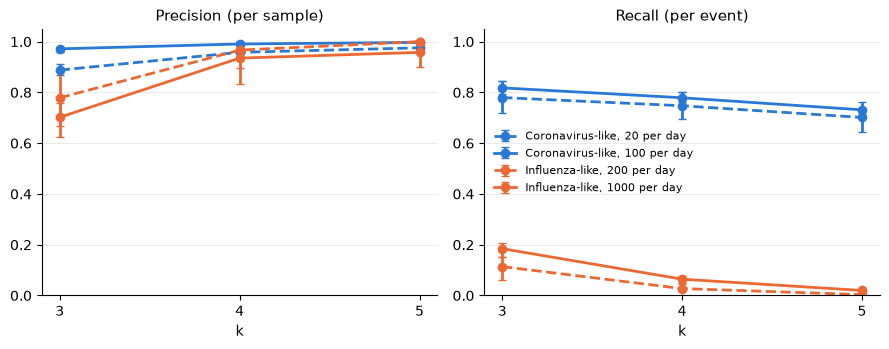

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6), sharex=True)
for ax, column, title in zip(
    axes, ["precision", "recall"], ["Precision (per sample)", "Recall (per event)"]
):
    stats = over_replicates(summary, [column])[column]
    for pathogen in pathogens:
        for s in sample_sizes[pathogen]:
            df = stats.loc[(pathogen, s)]
            ax.errorbar(
                df.index, df["mean"], yerr=[df["mean"] - df["min"], df["max"] - df["mean"]],
                marker="o", markersize=6, linewidth=2, capsize=3,
                linestyle=s_style(pathogen, s), color=pathogen_colors[pathogen],
                label=f"{pathogen_labels[pathogen]}, {s} per day",
            )
    ax.set_title(title, fontsize=11)
    ax.set_xticks(k_values)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("k")
    clean_axes(ax)
axes[1].legend(frameon=False, fontsize=8)
fig.tight_layout()

## Which events are found

Detectable events (where the recombinant differs from both its parents; the rest leave
no trace), split by whether the recombinant itself was sampled and placed, or is only
seen through its descendants. Pooled over replicates.

Most events are only seen through descendants, and sc2ts finds those at least as often
as recombinants that were themselves sampled: for the coronavirus-like pathogen at
$k = 4$, 0.80 and 0.83 of events seen only through descendants are found (20 and 100
per day), against 0.74 and 0.80 of sampled recombinants.

About 95% of coronavirus-like events are detectable, against about 81% of
influenza-like events (second table).

In [8]:
events["kind"] = np.where(events.sampled, "recombinant sampled", "descendants only")
detectable = events[events.detectable]
(
    detectable.groupby(["pathogen", "samples_per_day", "k", "kind"])
    .detected.agg(["size", "mean"])
    .rename(columns={"size": "events", "mean": "recall"})
    .unstack("kind")
    .round(3)
)

events                      \
kind                               descendants only recombinant sampled   
pathogen         samples_per_day k                                        
coronavirus_like 20              3              677                 103   
                                 4              677                 103   
                                 5              677                 103   
                 100             3             1203                 473   
                                 4             1203                 473   
                                 5             1203                 473   
flu_like         200             3             1083                  53   
                                 4             1083                  53   
                                 5             1083                  53   
                 1000            3             3895                 213   
                                 4             3895                 213   
                                 5             3895                 213   

                                             recall                      
kind                               descendants only recombinant sampled  
pathogen         samples_per_day k                                       
coronavirus_like 20              3            0.836               0.748  
                                 4            0.798               0.738  
                                 5            0.750               0.689  
                 100             3            0.865               0.850  
                                 4            0.826               0.803  
                                 5            0.774               0.761  
flu_like         200             3            0.141               0.094  
                                 4            0.035               0.000  
                                 5            0.005               0.000  
                 1000            3            0.226               0.188  
                                 4            0.079               0.056  
                                 5            0.024               0.028

In [9]:
events.groupby(["pathogen", "samples_per_day"]).detectable.mean().round(3)

pathogen          samples_per_day
coronavirus_like  20                 0.947
                  100                0.950
flu_like          200                0.813
                  1000               0.819
Name: detectable, dtype: float64

## Exact matches

A sample identical to a node already in the ARG is not given a node of its own during
inference, only counted against the node it matches; `sc2ts postprocess` adds these
exact matches as nodes under that node. Pooled over replicates.

**Coronavirus-like.** With about 0.36 mutations per genome per generation, many samples
are identical to a sampled relative: 11% of samples with 20 per day and 28% with 100
per day, and the fraction is about constant once the population has grown.

**Influenza-like.** 27% and 31% of samples are exact matches. Early on, while the
population grows from a single founder, there are hardly any mutations yet and nearly
every sample is identical to one already in the ARG. The fraction then falls as
diversity builds up, to 2% and 6% over the last 20 days.

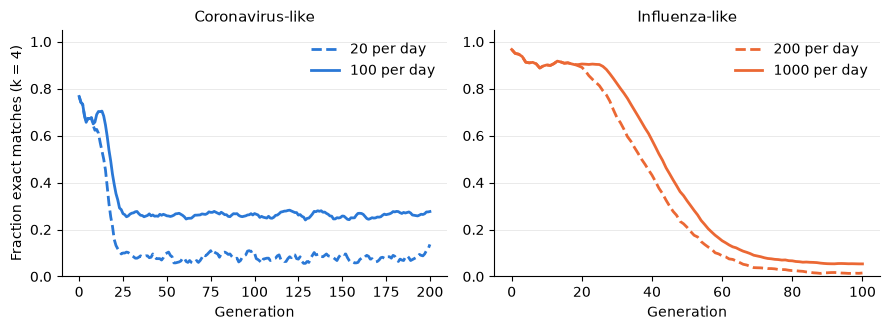

In [10]:
fig, axes = plt.subplots(1, len(pathogens), figsize=(4.5 * len(pathogens), 3.4))
for ax, pathogen in zip(axes, pathogens):
    for s in sample_sizes[pathogen]:
        df = placement[
            (placement.pathogen == pathogen)
            & (placement.samples_per_day == s)
            & (placement.k == PAPER_K)
        ].groupby("gen")[["num_samples", "num_exact_matches"]].sum()
        rate = df.num_exact_matches / df.num_samples
        # Smooth over 5 generations: there are few samples per generation at low S.
        smooth = rate.rolling(5, center=True, min_periods=1).mean()
        ax.plot(
            smooth.index, smooth.values, linewidth=2, linestyle=s_style(pathogen, s),
            color=pathogen_colors[pathogen], label=f"{s} per day",
        )
    ax.set_title(pathogen_labels[pathogen], fontsize=11)
    ax.set_xlabel("Generation")
    ax.set_ylim(0, 1.05)
    ax.legend(frameon=False)
    clean_axes(ax)
axes[0].set_ylabel(f"Fraction exact matches (k = {PAPER_K})")
fig.tight_layout()

In [11]:
df = placement[placement.k == PAPER_K]
totals = df.groupby(["pathogen", "samples_per_day"])[["num_samples", "num_exact_matches"]].sum()
late = df[df.gen >= df.groupby("pathogen").gen.transform("max") - 19]
late_totals = late.groupby(["pathogen", "samples_per_day"])[
    ["num_samples", "num_exact_matches"]
].sum()
pd.DataFrame({
    "exact_matches": totals.num_exact_matches / totals.num_samples,
    "exact_matches_last_20_gens": late_totals.num_exact_matches / late_totals.num_samples,
}).round(3)

exact_matches  exact_matches_last_20_gens
pathogen         samples_per_day                                           
coronavirus_like 20                       0.112                       0.087
                 100                      0.281                       0.270
flu_like         200                      0.274                       0.016
                 1000                     0.309                       0.057

## Breakpoints

Breakpoint intervals run from the last site supporting the left parent to the first
supporting the right. For events found with a single breakpoint, taking the earliest
sample the event was found in, we compare the interval with the true breakpoint, and
its width with the median in the real Viridian ARG (dashed line, 2,018 bases).

**Coronavirus-like.** The true breakpoint falls in the interval for 96% of detected
events with 20 samples per day and 99% with 100, at every $k$. Median interval widths
are 740-800 bases, about 2.5% of the genome, and narrower than in the real ARG.

**Influenza-like.** Median interval widths are 1,300-1,900 bases, 10-15% of the 13 kb
genome, and the true breakpoint is in the interval for 83-92% of detected events
(mean over replicates; few events are found at $k = 5$, so the range is wide there).

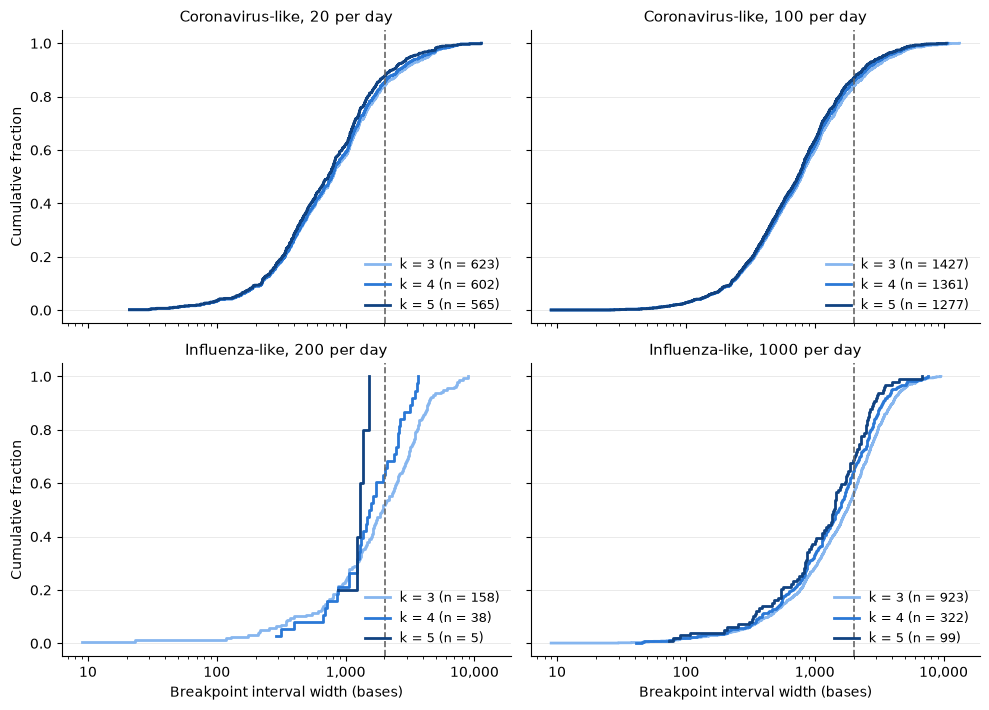

In [12]:
# Events found with a single breakpoint have an interval.
found = events.dropna(subset=["interval_width"])

num_columns = max(len(values) for values in sample_sizes.values())
fig, axes = plt.subplots(
    len(pathogens), num_columns, figsize=(5 * num_columns, 3.6 * len(pathogens)),
    sharex=True, sharey=True, squeeze=False,
)
for row, pathogen in zip(axes, pathogens):
    for ax, s in zip(row, sample_sizes[pathogen]):
        for k in k_values:
            df = found[
                (found.pathogen == pathogen) & (found.samples_per_day == s) & (found.k == k)
            ]
            width = np.sort(df.interval_width.values)
            ax.step(
                width, np.arange(1, len(width) + 1) / len(width), where="post",
                linewidth=2, color=k_colors[k], label=f"k = {k} (n = {len(width)})",
            )
        ax.axvline(PAPER_MEDIAN_INTERVAL, color="0.4", linestyle="--", linewidth=1.2)
        ax.set_title(f"{pathogen_labels[pathogen]}, {s} per day", fontsize=11)
        ax.set_xscale("log")
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
        ax.xaxis.set_minor_formatter(mticker.NullFormatter())
        ax.legend(frameon=False, loc="lower right", fontsize=9)
        clean_axes(ax)
    row[0].set_ylabel("Cumulative fraction")
for ax in axes[-1]:
    ax.set_xlabel("Breakpoint interval width (bases)")
fig.tight_layout()

In [13]:
pd.DataFrame({
    # Pooled over replicates.
    "median_width": found.groupby(["pathogen", "samples_per_day", "k"]).interval_width.median(),
    "median_width_fraction_of_genome": found.groupby(
        ["pathogen", "samples_per_day", "k"]
    ).interval_width.median()
    / found.groupby(["pathogen", "samples_per_day", "k"]).pathogen.first().map(
        lambda p: config["pathogens"][p]["slim"]["L"]
    ),
}).round(3)

median_width  \
pathogen         samples_per_day k                 
coronavirus_like 20              3         798.0   
                                 4         781.0   
                                 5         735.0   
                 100             3         790.0   
                                 4         772.0   
                                 5         740.0   
flu_like         200             3        1926.5   
                                 4        1541.0   
                                 5        1291.0   
                 1000            3        1778.0   
                                 4        1533.5   
                                 5        1410.0   

                                    median_width_fraction_of_genome  
pathogen         samples_per_day k                                   
coronavirus_like 20              3                            0.027  
                                 4                            0.026  
                                 5                            0.024  
                 100             3                            0.026  
                                 4                            0.026  
                                 5                            0.025  
flu_like         200             3                            0.148  
                                 4                            0.119  
                                 5                            0.099  
                 1000            3                            0.137  
                                 4                            0.118  
                                 5                            0.108

## ARG accuracy

`tscompare.haplotype_arf(inferred, true)`, over all placed samples. `arf` is the
fraction of the inferred ARG's node span not found in the true ARG, `tpr` the fraction
of the true ARG's span found in the inferred one, and `rmse` the error in log node
times (in generations) of matched nodes. $k$ makes almost no difference to any of
them: recombination is rare enough that the clonal topology dominates.

Over all nodes, ARF is 0.18 and 0.22 for the coronavirus-like pathogen (20 and 100 per
day) and 0.19 and 0.21 for the influenza-like one, with TPR of 0.63 and 0.59, and 0.54
and 0.52. Accuracy is lower with denser sampling, as there are more exact matches:
identical sequences carry no information about how they are related, and sc2ts
places them all directly under the node they match, while the true genealogy among
them is resolved. Samples also make up much of both ARGs.

The second table is the fairer measure: non-sample nodes only, after reducing both ARGs
to what the sequences can resolve (see the README). ARF is then 0.04-0.07 and TPR
0.91-0.94 for the coronavirus-like pathogen, and ARF 0.08-0.11 and TPR 0.88-0.92 for
the influenza-like one, slightly better with denser sampling.

In [14]:
over_replicates(summary, ["arf", "tpr", "rmse"]).round(3)

arf                  tpr                \
                                     mean    min    max   mean    min    max   
pathogen         samples_per_day k                                             
coronavirus_like 20              3  0.179  0.177  0.187  0.632  0.621  0.636   
                                 4  0.178  0.176  0.186  0.634  0.623  0.638   
                                 5  0.179  0.175  0.186  0.634  0.624  0.638   
                 100             3  0.224  0.222  0.226  0.594  0.591  0.597   
                                 4  0.224  0.222  0.226  0.594  0.591  0.597   
                                 5  0.225  0.223  0.227  0.594  0.591  0.597   
flu_like         200             3  0.186  0.185  0.188  0.537  0.534  0.540   
                                 4  0.186  0.185  0.187  0.537  0.534  0.540   
                                 5  0.186  0.185  0.187  0.537  0.534  0.540   
                 1000            3  0.215  0.213  0.217  0.524  0.523  0.525   
                                 4  0.214  0.213  0.216  0.525  0.524  0.526   
                                 5  0.214  0.213  0.216  0.525  0.524  0.526   

                                     rmse                
                                     mean    min    max  
pathogen         samples_per_day k                       
coronavirus_like 20              3  0.064  0.054  0.076  
                                 4  0.065  0.056  0.075  
                                 5  0.065  0.056  0.075  
                 100             3  0.038  0.036  0.040  
                                 4  0.038  0.036  0.040  
                                 5  0.038  0.036  0.040  
flu_like         200             3  0.091  0.085  0.097  
                                 4  0.091  0.085  0.097  
                                 5  0.091  0.085  0.097  
                 1000            3  0.119  0.115  0.123  
                                 4  0.118  0.114  0.122  
                                 5  0.118  0.114  0.123

In [15]:
over_replicates(summary, ["arf_internal_resolved", "tpr_internal_resolved"]).round(3)

arf_internal_resolved                \
                                                    mean    min    max   
pathogen         samples_per_day k                                       
coronavirus_like 20              3                 0.063  0.055  0.072   
                                 4                 0.063  0.053  0.071   
                                 5                 0.067  0.058  0.078   
                 100             3                 0.044  0.043  0.045   
                                 4                 0.045  0.043  0.046   
                                 5                 0.048  0.045  0.049   
flu_like         200             3                 0.103  0.091  0.113   
                                 4                 0.105  0.093  0.113   
                                 5                 0.107  0.095  0.114   
                 1000            3                 0.079  0.075  0.086   
                                 4                 0.079  0.075  0.085   
                                 5                 0.080  0.076  0.087   

                                   tpr_internal_resolved                
                                                    mean    min    max  
pathogen         samples_per_day k                                      
coronavirus_like 20              3                 0.914  0.898  0.922  
                                 4                 0.916  0.901  0.926  
                                 5                 0.914  0.897  0.922  
                 100             3                 0.943  0.941  0.945  
                                 4                 0.942  0.940  0.945  
                                 5                 0.940  0.938  0.944  
flu_like         200             3                 0.888  0.883  0.894  
                                 4                 0.885  0.882  0.892  
                                 5                 0.884  0.879  0.890  
                 1000            3                 0.915  0.910  0.917  
                                 4                 0.916  0.911  0.918  
                                 5                 0.914  0.910  0.916

## Mutations averted

As for the published ARG, each recombinant node is rematched against the ARG for the
day before it was added, forced to a single parent. `mutations_averted` is the number
of mutations that match needs (`k1000_muts`) less the number in the recombinant match
(`num_mutations`): the measure of support for recombinants used in the paper. Here we
can see how it relates to the truth. A node is a true positive if any of the samples
that created it is expected to be a recombinant. These are per node, so differ
slightly from the per-sample precision above.

**Coronavirus-like.** True positives avert a median of 15-19 mutations, and up to
about 120; false positives avert $k$ (median) and never more than 11.

**Influenza-like.** True and false positives alike avert $k$ or barely more (medians
equal to $k$, maximum 9): there is little to tell them apart.

In [16]:
(
    recombinants.groupby(["pathogen", "samples_per_day", "k", "true_positive"])
    .mutations_averted.describe()
    .round(1)
)

count  mean   std  min  \
pathogen         samples_per_day k true_positive                            
coronavirus_like 20              3 False            79.0   3.5   1.3  0.0   
                                   True            663.0  23.5  21.9  0.0   
                                 4 False            24.0   4.8   1.6  3.0   
                                   True            628.0  23.4  21.1  0.0   
                                 5 False            13.0   5.6   1.8  4.0   
                                   True            584.0  24.3  20.6  4.0   
                 100             3 False            42.0   3.3   1.0  1.0   
                                   True           1443.0  27.6  25.2  1.0   
                                 4 False            12.0   4.2   1.5  1.0   
                                   True           1373.0  27.8  24.9  2.0   
                                 5 False             4.0   5.8   1.0  5.0   
                                   True           1289.0  28.2  24.3  4.0   
flu_like         200             3 False            42.0   3.0   0.2  3.0   
                                   True            158.0   3.3   0.5  3.0   
                                 4 False             1.0   4.0   NaN  4.0   
                                   True             38.0   4.1   0.3  4.0   
                                 5 True              5.0   5.0   0.0  5.0   
                 1000            3 False           392.0   3.1   0.4 -1.0   
                                   True            927.0   3.5   0.8  1.0   
                                 4 False            22.0   4.2   0.4  4.0   
                                   True            322.0   4.4   0.8  4.0   
                                 5 False             4.0   5.0   0.0  5.0   
                                   True             99.0   5.4   0.7  5.0   

                                                  25%   50%   75%    max  
pathogen         samples_per_day k true_positive                          
coronavirus_like 20              3 False          3.0   3.0   4.0   11.0  
                                   True           7.0  15.0  34.0  109.0  
                                 4 False          4.0   4.0   5.0   11.0  
                                   True           8.0  15.0  33.0  109.0  
                                 5 False          5.0   5.0   6.0   11.0  
                                   True           9.0  16.0  34.0  104.0  
                 100             3 False          3.0   3.0   3.0    7.0  
                                   True           7.0  19.0  40.0  123.0  
                                 4 False          4.0   4.0   5.0    7.0  
                                   True           8.0  19.0  40.0  122.0  
                                 5 False          5.0   5.5   6.2    7.0  
                                   True           9.0  19.0  40.0  122.0  
flu_like         200             3 False          3.0   3.0   3.0    4.0  
                                   True           3.0   3.0   3.0    5.0  
                                 4 False          4.0   4.0   4.0    4.0  
                                   True           4.0   4.0   4.0    5.0  
                                 5 True           5.0   5.0   5.0    5.0  
                 1000            3 False          3.0   3.0   3.0    5.0  
                                   True           3.0   3.0   4.0    9.0  
                                 4 False          4.0   4.0   4.0    5.0  
                                   True           4.0   4.0   5.0    9.0  
                                 5 False          5.0   5.0   5.0    5.0  
                                   True           5.0   5.0   6.0    8.0

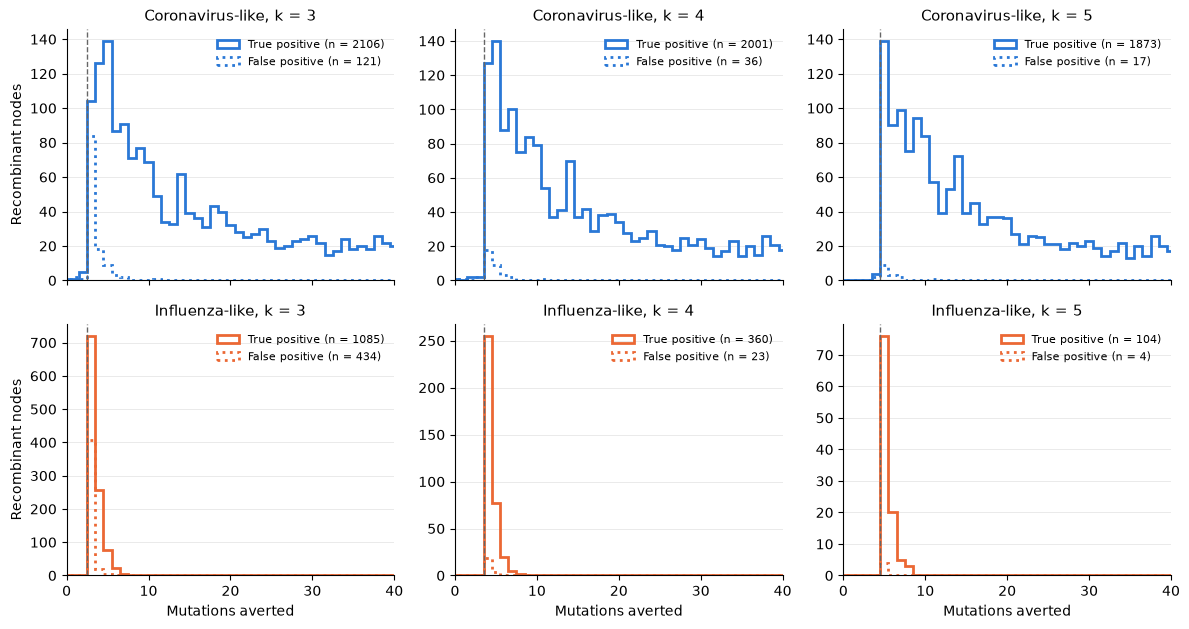

In [17]:
bins = np.arange(recombinants.mutations_averted.max() + 2) - 0.5
fig, axes = plt.subplots(
    len(pathogens), len(k_values), figsize=(4 * len(k_values), 3.2 * len(pathogens)),
    sharex=True, squeeze=False,
)
for row, pathogen in zip(axes, pathogens):
    for ax, k in zip(row, k_values):
        df = recombinants[(recombinants.pathogen == pathogen) & (recombinants.k == k)]
        for true_positive, linestyle, label in [
            (True, "-", "True positive"), (False, ":", "False positive")
        ]:
            values = df.mutations_averted[df.true_positive == true_positive]
            ax.hist(
                values, bins=bins, histtype="step", linewidth=2, linestyle=linestyle,
                color=pathogen_colors[pathogen], label=f"{label} (n = {len(values)})",
            )
        ax.axvline(k - 0.5, color="0.4", linestyle="--", linewidth=1)
        ax.set_title(f"{pathogen_labels[pathogen]}, k = {k}", fontsize=11)
        ax.set_xlim(0, 40)
        ax.legend(frameon=False, fontsize=8)
        clean_axes(ax)
    row[0].set_ylabel("Recombinant nodes")
for ax in axes[-1]:
    ax.set_xlabel("Mutations averted")
fig.tight_layout()

Requiring a minimum number of mutations averted removes false positives at the cost
of true ones. For each cutoff, the precision of the nodes kept and the fraction of
true-positive nodes kept, pooled over sampling densities and replicates. For the
coronavirus-like pathogen at $k = 4$, requiring 5 (one more than a tie) raises
precision from 0.984 to 0.992 and keeps 93% of true positives. For the influenza-like
pathogen it keeps under a third of them.

In [18]:
rows = []
for (pathogen, k), df in recombinants.groupby(["pathogen", "k"]):
    for cutoff in range(k, k + 6):
        kept = df[df.mutations_averted >= cutoff]
        rows.append({
            "pathogen": pathogen,
            "k": k,
            "cutoff": cutoff,
            "precision": kept.true_positive.mean() if len(kept) > 0 else np.nan,
            "true_positives_kept": kept.true_positive.sum() / df.true_positive.sum(),
        })
pd.DataFrame(rows).set_index(["pathogen", "k", "cutoff"]).round(3)

precision  true_positives_kept
pathogen         k cutoff                                
coronavirus_like 3 3           0.947                0.997
                   4           0.984                0.947
                   5           0.992                0.887
                   6           0.997                0.821
                   7           0.998                0.780
                   8           0.999                0.737
                 4 4           0.984                0.998
                   5           0.992                0.934
                   6           0.997                0.864
                   7           0.998                0.820
                   8           0.999                0.770
                   9           0.999                0.733
                 5 5           0.992                0.998
                   6           0.997                0.924
                   7           0.998                0.876
                   8           0.999                0.823
                   9           0.999                0.783
                   10          0.999                0.733
flu_like         3 3           0.715                0.998
                   4           0.938                0.335
                   5           0.964                0.099
                   6           1.000                0.028
                   7           1.000                0.007
                   8           1.000                0.003
                 4 4           0.940                1.000
                   5           0.963                0.292
                   6           1.000                0.078
                   7           1.000                0.022
                   8           1.000                0.008
                   9           1.000                0.003
                 5 5           0.963                1.000
                   6           1.000                0.269
                   7           1.000                0.077
                   8           1.000                0.029
                   9             NaN                0.000
                   10            NaN                0.000

## False positives

`tie` is whether the single-parent match costs the same as the recombinant one
(`mutations_averted` equal to $k$ times the number of breakpoints), which sc2ts
resolved in favour of recombination. Half or more of false positives are ties
(coronavirus-like) and nearly all (influenza-like), against 5-8% of coronavirus-like
true positives. Influenza-like true positives are mostly ties too.

False-positive recombinant nodes are put into one of two categories, from the true
ARG (see the pipeline README):

- `relative_recombinant`: the sample's nearest earlier-sampled relatives change along
  the genome, because a relative is (or descends from) a recombinant. The
  recombination is real, but placed on the wrong lineage, usually with the relative's
  breakpoint.
- `unresolved_branch`: they don't, and the ARG has no node close to the sample's true
  ancestor.

Most coronavirus-like false positives (113 of 174) are `relative_recombinant`, and for
83% of these the relative's breakpoint is in the inferred interval. Most
influenza-like false positives (412 of 461, nearly all at $k = 3$ with 1,000 per day)
are `unresolved_branch` ties.

In [19]:
# A tie: the single-parent match costs the same as the recombinant one.
recombinants["tie"] = recombinants.mutations_averted == recombinants.k * (
    recombinants.num_parents - 1
)
recombinants.groupby(["pathogen", "k", "true_positive"]).tie.mean().unstack().round(3)

true_positive       False  True 
pathogen         k              
coronavirus_like 3  0.694  0.049
                 4  0.500  0.063
                 5  0.529  0.075
flu_like         3  0.938  0.665
                 4  0.826  0.708
                 5  1.000  0.731

In [20]:
fp = recombinants[~recombinants.true_positive]
pd.crosstab([fp.pathogen, fp.samples_per_day, fp.k], [fp.category, fp.tie], margins=True)

category                           relative_recombinant       \
tie                                               False True   
pathogen         samples_per_day k                             
coronavirus_like 20              3                   22   18   
                                 4                   11   11   
                                 5                    6    7   
                 100             3                    9   15   
                                 4                    5    5   
                                 5                    2    2   
flu_like         200             3                    0    6   
                                 4                    0    0   
                 1000            3                    9   25   
                                 4                    2    5   
                                 5                    0    2   
All                                                  66   96   

category                           unresolved_branch       All  
tie                                            False True       
pathogen         samples_per_day k                              
coronavirus_like 20              3                 3   36   79  
                                 4                 1    1   24  
                                 5                 0    0   13  
                 100             3                 3   15   42  
                                 4                 1    1   12  
                                 5                 0    0    4  
flu_like         200             3                 1   35   42  
                                 4                 0    1    1  
                 1000            3                17  341  392  
                                 4                 2   13   22  
                                 5                 0    2    4  
All                                               28  445  635

In [21]:
# How often the relative's breakpoint is in the inferred breakpoint interval.
(
    fp[fp.category == "relative_recombinant"]
    .groupby("pathogen")
    .relative_breakpoint_in_interval.agg(["size", "mean"])
    .round(3)
)

,size,mean
pathogen,,
coronavirus_like,113,0.831858
flu_like,49,0.632653


## Figure for the paper

(A) Precision and (B) recall against $k$, mean and range over replicates. (C) Recall
at $k = 4$ of detectable events, by whether the recombinant was sampled. (D) Breakpoint
interval widths at $k = 4$, pooled over replicates. (E) Mutations averted by true- and
false-positive recombinant nodes at $k = 4$, pooled over sampling densities and
replicates. (F) ARF and TPR over non-sample nodes of the reduced ARGs at $k = 4$.

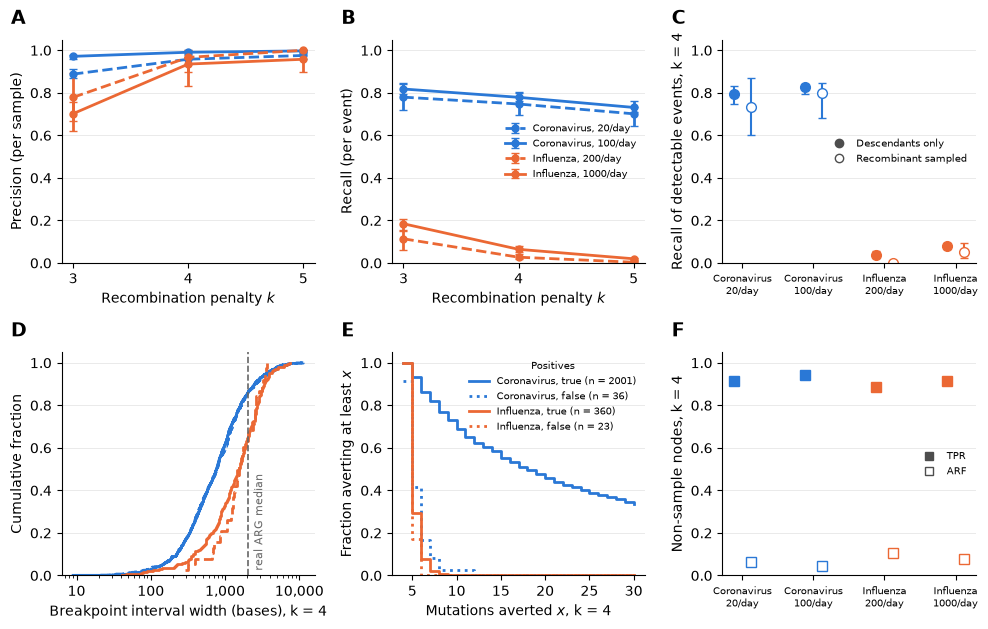

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6.4))
ax_precision, ax_recall, ax_sampled, ax_interval, ax_averted, ax_arf = axes.flat
runs = [(pathogen, s) for pathogen in pathogens for s in sample_sizes[pathogen]]
run_labels = [f"{pathogen_labels[p].split('-')[0]}\n{s}/day" for p, s in runs]


def errorbar(ax, x, values, **kwargs):
    mean, low, high = (np.atleast_1d(values[c]) for c in ["mean", "min", "max"])
    ax.errorbar(x, mean, yerr=[mean - low, high - mean], capsize=3, **kwargs)


# A, B: precision and recall against k.
for ax, column, ylabel in [
    (ax_precision, "precision", "Precision (per sample)"),
    (ax_recall, "recall", "Recall (per event)"),
]:
    stats = over_replicates(summary, [column])[column]
    for pathogen, s in runs:
        errorbar(
            ax, k_values, stats.loc[(pathogen, s)], marker="o", markersize=5,
            linewidth=2, linestyle=s_style(pathogen, s), color=pathogen_colors[pathogen],
            label=f"{pathogen_labels[pathogen].split('-')[0]}, {s}/day",
        )
    ax.set_xticks(k_values)
    ax.set_xlabel("Recombination penalty $k$")
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 1.05)
ax_recall.legend(frameon=False, fontsize=7, loc="center right")

# C: recall at k = 4 of detectable events, by whether the recombinant was sampled.
per_run = (
    detectable[detectable.k == PAPER_K]
    .groupby(["pathogen", "samples_per_day", "kind", "rep"])
    .detected.mean()
    .groupby(["pathogen", "samples_per_day", "kind"])
    .agg(["mean", "min", "max"])
)
x = np.arange(len(runs))
for kind, offset, fill in [("descendants only", -0.12, True), ("recombinant sampled", 0.12, False)]:
    for j, (pathogen, s) in enumerate(runs):
        color = pathogen_colors[pathogen]
        errorbar(
            ax_sampled, [j + offset], per_run.loc[(pathogen, s, kind)], marker="o",
            markersize=7, linewidth=0, elinewidth=1.5, color=color,
            markerfacecolor=color if fill else "white",
        )
    ax_sampled.plot([], [], marker="o", linewidth=0, color="0.3",
                    markerfacecolor="0.3" if fill else "white", label=kind.capitalize())
ax_sampled.set_xticks(x)
ax_sampled.set_xticklabels(run_labels, fontsize=7)
ax_sampled.set_ylabel(f"Recall of detectable events, k = {PAPER_K}")
ax_sampled.set_ylim(0, 1.05)
ax_sampled.legend(frameon=False, fontsize=7, loc="center right")

# D: breakpoint interval widths at k = 4, pooled over replicates.
for pathogen, s in runs:
    width = np.sort(found[
        (found.pathogen == pathogen) & (found.samples_per_day == s) & (found.k == PAPER_K)
    ].interval_width.values)
    ax_interval.step(
        width, np.arange(1, len(width) + 1) / len(width), where="post", linewidth=2,
        linestyle=s_style(pathogen, s), color=pathogen_colors[pathogen],
    )
ax_interval.axvline(PAPER_MEDIAN_INTERVAL, color="0.4", linestyle="--", linewidth=1.2)
ax_interval.annotate("real ARG median", xy=(PAPER_MEDIAN_INTERVAL, 0.25), xytext=(4, 0),
                     textcoords="offset points", rotation=90, ha="left", va="center",
                     fontsize=8, color="0.4")
ax_interval.set_xscale("log")
ax_interval.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax_interval.xaxis.set_minor_formatter(mticker.NullFormatter())
ax_interval.set_xlabel(f"Breakpoint interval width (bases), k = {PAPER_K}")
ax_interval.set_ylabel("Cumulative fraction")
ax_interval.set_ylim(0, 1.05)

# E: mutations averted by true- and false-positive recombinant nodes at k = 4,
# pooled over sampling densities and replicates.
for pathogen in pathogens:
    df = recombinants[(recombinants.pathogen == pathogen) & (recombinants.k == PAPER_K)]
    for true_positive, linestyle, label in [(True, "-", "true"), (False, ":", "false")]:
        values = np.sort(df.mutations_averted[df.true_positive == true_positive].values)
        thresholds = np.arange(PAPER_K, 31)
        kept = [(values >= t).mean() for t in thresholds]
        ax_averted.step(
            thresholds, kept, where="post", linewidth=2, linestyle=linestyle,
            color=pathogen_colors[pathogen],
            label=f"{pathogen_labels[pathogen].split('-')[0]}, {label} (n = {len(values)})",
        )
ax_averted.set_xlabel(f"Mutations averted $x$, k = {PAPER_K}")
ax_averted.set_ylabel("Fraction averting at least $x$")
ax_averted.set_ylim(0, 1.05)
ax_averted.legend(frameon=False, fontsize=7, loc="upper right", title="Positives", title_fontsize=7)

# F: ARF and TPR over non-sample nodes of the reduced ARGs at k = 4.
for column, offset, fill, label in [
    ("tpr_internal_resolved", -0.12, True, "TPR"),
    ("arf_internal_resolved", 0.12, False, "ARF"),
]:
    stats = over_replicates(summary[summary.k == PAPER_K], [column])[column]
    for j, (pathogen, s) in enumerate(runs):
        color = pathogen_colors[pathogen]
        errorbar(
            ax_arf, [j + offset], stats.loc[(pathogen, s, PAPER_K)], marker="s",
            markersize=7, linewidth=0, elinewidth=1.5, color=color,
            markerfacecolor=color if fill else "white",
        )
    ax_arf.plot([], [], marker="s", linewidth=0, color="0.3",
                markerfacecolor="0.3" if fill else "white", label=label)
ax_arf.set_xticks(x)
ax_arf.set_xticklabels(run_labels, fontsize=7)
ax_arf.set_ylabel(f"Non-sample nodes, k = {PAPER_K}")
ax_arf.set_ylim(0, 1.05)
ax_arf.legend(frameon=False, fontsize=7, loc="center right")

for ax, letter in zip(axes.flat, "ABCDEF"):
    clean_axes(ax)
    ax.text(-0.2, 1.05, letter, transform=ax.transAxes, fontsize=14,
            fontweight="bold", va="bottom")
fig.tight_layout()
fig.savefig("../figures/slim_simulations.pdf")

## Notes

- Turning off sc2ts's time-traveller filtering made the biggest difference at low
  sampling density: in an earlier coronavirus-like run with the Viridian settings
  (`hmm_cost_threshold` 7) and about 20 samples per day, 39% of samples were held back
  and never added, and recall was only 0.41, 0.31 and 0.17 for $k = 3, 4, 5$.
- The 100-day influenza-like simulations correspond to the start of an epidemic, before
  much diversity has built up. The recombinants found in the Viridian ARG are mostly
  between lineages that had been diverging for a year or more.